# Hands-On Project: Stellar Luminosity

## 1. Establishing environment

In [1]:
# Required libraries
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

# Libraries' versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.5.1
Matplotlib version: 3.11.1



As we are using NumPy library, then we are going to load the dataset as NumPy arrays:

In [3]:
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Shapes of the arrays
print("Mass shape:", mass.shape)
print("Luminosity shape:", luminosity.shape)

# Ranges of the variables
print("Mass range:", mass.min(), "to", mass.max())
print("Luminosity range:", luminosity.min(), "to", luminosity.max())

Mass shape: (10,)
Luminosity shape: (10,)
Mass range: 0.6 to 2.4
Luminosity range: 0.15 to 35.0


___

## 2. Exploring before modeling

We are going to plot stellar mass against luminosity

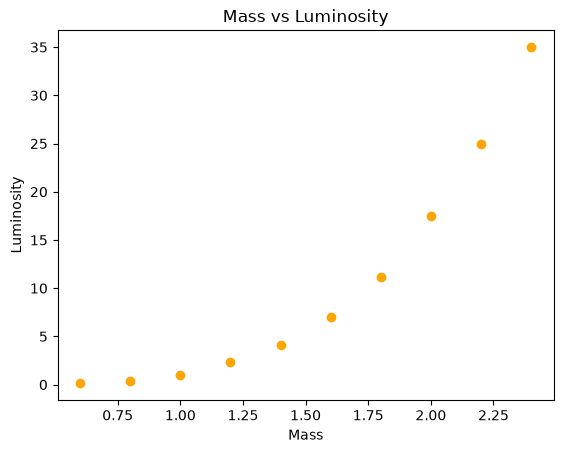

In [4]:
# First we create a new empty figure
plt.figure()

# Now we plot the data points
plt.scatter(mass, luminosity, color="orange")

# Then, we add labels and a title
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Mass vs Luminosity")

# Finally, we show the plot
plt.show()

### Describing the observed relation

The relationship between stellar mass and luminosity appears to be nonlinear. It's clear to see that as the stellar mass increases, the luminosity increases at a much faster rate, suggesting an upward-curving trend rather than a straight line.

A straight line does not appear to be adequate because it cannot fully capture the curved pattern. It would likely overestimate the luminosity of some stars and underestimate it for others, especially near the beginning and the end of the observed range. These systematic errors suggest that a nonlinear model may provide a better fit.

___

## 3. Implementing the learning algorithm

We'll use the model:

$$
f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

where:
 - $w$ is the slope,
 - $b$ the intercept.

In [5]:
def predict(X, w, b):
    return X @ w + b

We define the **mean squared error** as the cost function, just as it was made in class:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$



In [6]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    errors = predict(X, w, b) - y
    cost = np.sum(errors**2) / (2*m) # Is it possible to use predict()?
    return cost

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$

In [7]:
def compute_gradients(X,y,w,b):
    m = X.shape[0]

    errors = predict(X, w, b) - y

    # Derivative of the cost function with respect to w
    df_dw = (X.T @ errors) / m

    # Derivative of the cost function with respect to b
    df_db = np.sum(errors) / m

    return df_dw, df_db

Now, let's implement the gradient descent loop:

In [8]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        # Compute gradients
        df_dw, df_db = compute_gradients(X, y, w, b)

        # Update parameters
        w = w - alpha * df_dw
        b = b - alpha * df_db

        # Save the cost
        cost = compute_cost(X, y, w, b)
        history.append((i, cost))

        # We are going to print the cost every 100 iterations
        if i % max(1, num_iterations // 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"w = {np.round(w, 4)}, "
                f"b = {b:7.4f}, "
                f"cost = {cost:8.4f}"
            )

    return w, b, history

We can see that this functions support design matrices thanks with one or more features thanks to NumPy library

___
## 4. Training a linear model

It is time to initialize the paramenters and choose a learning rate and a number of iterations.

For linear regression, gradient descent usually converges to the same solution regardless of the starting point, because the cost function is convex. Therefore, we will use the simplest initialization by setting both parameters to zero.

We will also choose a reasonable learning rate: not too large and not too small. Finally, we will select a number of iterations that is large enough for the algorithm to converge.

In [9]:
# Design matrix for the linear model
X_linear = mass.reshape(-1, 1) # Reshape to a column vector

# Is that what the workshop meant? X_linear = [mass]

w = np.zeros(X_linear.shape[1])
b = 0.0
alpha = 0.01
num_iterations = 1000

Now, we are going to train the model.

In [10]:
w_learned, b_learned, cost_history = gradient_descent(X_linear, luminosity, w, b, alpha, num_iterations)

print("Learned parameters:")
print("w = ", w_learned)
print("b = ", b_learned)

Iteration    0: w = [0.2152], b =  0.1036, cost = 112.0896
Iteration  100: w = [6.8004], b =  1.5699, cost =  31.9704
Iteration  200: w = [7.9674], b = -0.0073, cost =  28.0913
Iteration  300: w = [8.89], b = -1.5257, cost =  24.9336
Iteration  400: w = [9.7253], b = -2.9093, cost =  22.3208
Iteration  500: w = [10.4849], b = -4.1680, cost =  20.1590
Iteration  600: w = [11.1759], b = -5.3129, cost =  18.3703
Iteration  700: w = [11.8044], b = -6.3543, cost =  16.8903
Iteration  800: w = [12.3762], b = -7.3015, cost =  15.6658
Iteration  900: w = [12.8962], b = -8.1632, cost =  14.6525
Learned parameters:
w =  [13.3647611]
b =  -8.939532714878704


To make better observations we are going to plot some model training behaviors

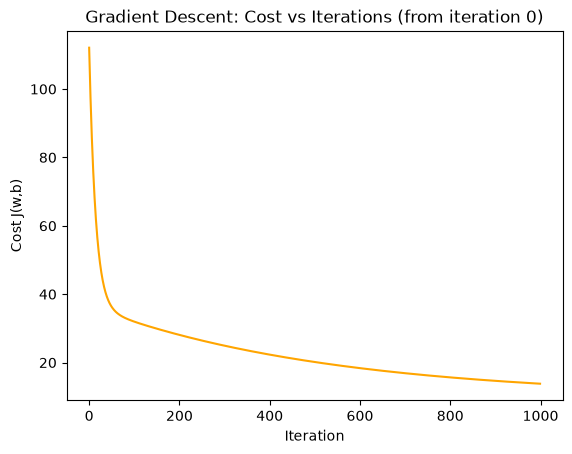

In [11]:
iterations = [it for it, c in cost_history]
cost = [c for it, c in cost_history]

# We can change this to zoom into the cost curve
start_iteration = 0

# Find the first index where the iteration is greater than or equal to start_iteration
start_index = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration:
        start_index = i
        break

fig , ax = plt.subplots()
ax.plot(iterations[start_index:], cost[start_index:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_iteration]})") # The iteration number is different in the workshop 3

# This keeps the labels as the actual cost values instead of scientific notation
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

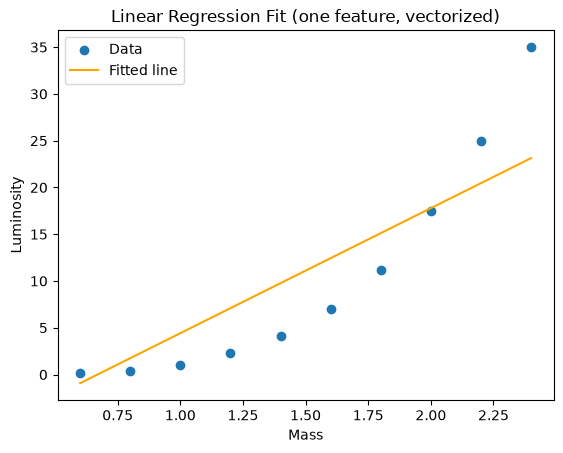

In [12]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred = predict(X_linear, w_learned, b_learned)

plt.plot(mass, y_pred, color="orange", label="Fitted line")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Linear Regression Fit (one feature, vectorized)")
plt.legend()
plt.show()

In [13]:
# Final parameter and cost values
print(f"Final parameters: w = {w_learned[0]}, b = {b_learned}")
print(f"Final cost: {cost_history[-1][1]}")

Final parameters: w = 13.364761102627167, b = -8.939532714878704
Final cost: 13.821822375363263


___
## 5. Training a polynomial model

Now, we are going to create the representation

$$
\textit{X\_polinomial} = [mass, mass^{2}]
$$

In [14]:
mass_sqr = [m**2 for m in mass]

Reusing the functions develop above we will train the polynomial model

In [15]:
# Design matrix for the polynomial model
X_polynomial = np.column_stack((mass, mass_sqr))

# The parameters initialization
w_poly = np.zeros(X_polynomial.shape[1])
b_poly = 0.0

# Training the polynomial model
alpha_poly = 0.0001
iterations_poly = 10000

w_learned_poly, b_learned_poly, cost_history_poly = gradient_descent(X_polynomial, luminosity, w_poly, b_poly, alpha_poly, iterations_poly)


Iteration    0: w = [0.0022 0.0046], b =  0.0010, cost = 117.4288
Iteration 1000: w = [1.1545 2.6351], b =  0.4904, cost =  21.2255
Iteration 2000: w = [1.3824 3.4438], b =  0.4776, cost =  13.3099
Iteration 3000: w = [1.3593 3.7494], b =  0.3324, cost =  12.0958
Iteration 4000: w = [1.27   3.9139], b =  0.1562, cost =  11.4302
Iteration 5000: w = [1.1652 4.0369], b = -0.0232, cost =  10.8465
Iteration 6000: w = [1.0586 4.1459], b = -0.1986, cost =  10.3064
Iteration 7000: w = [0.9539 4.2484], b = -0.3681, cost =   9.8045
Iteration 8000: w = [0.8521 4.3466], b = -0.5313, cost =   9.3379
Iteration 9000: w = [0.7534 4.4412], b = -0.6884, cost =   8.9041


Let's see some training model behaviors in a graph.

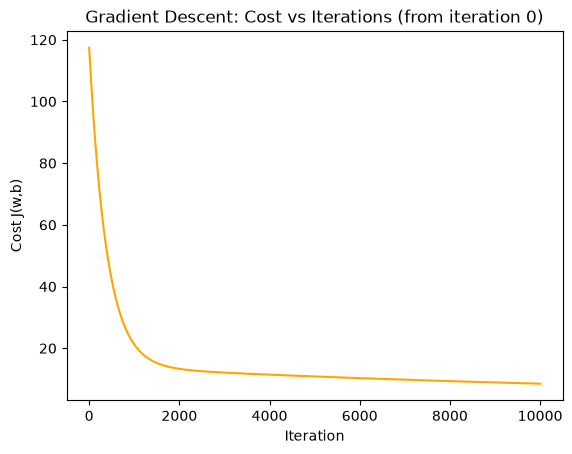

In [16]:
iterations = [it for it, c in cost_history_poly]
cost = [c for it, c in cost_history_poly]

start_iteration_poly = 0

start_index_poly = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration_poly:
        start_index_poly = i
        break

fig, ax = plt.subplots()
ax.plot(iterations[start_index_poly:], cost[start_index_poly:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_iteration]})")

ax.ticklabel_format(axis='y', style='plain', useOffset=False)

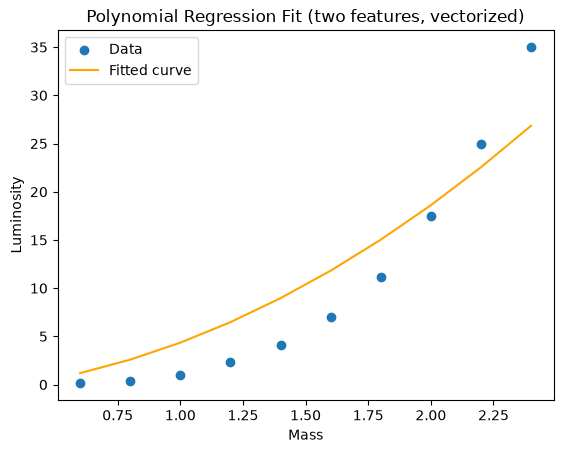

In [17]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred = predict(X_polynomial, w_learned_poly, b_learned_poly)

plt.plot(mass, y_pred, color="orange", label="Fitted curve")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Polynomial Regression Fit (two features, vectorized)")
plt.legend()
plt.show()